In [ ]:
import numpy as np

def fk_3link(theta1, theta2, theta3, l1, l2, l3):
    # base
    p0 = np.array([0, 0, 0])

    # joint1 (z offset)
    p1 = np.array([0, 0, l1])

    # joint2
    x2 = np.cos(theta1) * l2 * np.cos(theta2)
    y2 = np.sin(theta1) * l2 * np.cos(theta2)
    z2 = l1 + l2 * np.sin(theta2)
    p2 = np.array([x2, y2, z2])

    # end-effector
    x3 = np.cos(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2 + theta3))
    y3 = np.sin(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2 + theta3))
    z3 = l1 + l2*np.sin(theta2) + l3*np.sin(theta2 + theta3)
    p3 = np.array([x3, y3, z3])

    return p0, p1, p2, p3


In [ ]:
import matplotlib.pyplot as plt

def plot_robot(p0, p1, p2, p3):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    xs = [p0[0], p1[0], p2[0], p3[0]]
    ys = [p0[1], p1[1], p2[1], p3[1]]
    zs = [p0[2], p1[2], p2[2], p3[2]]

    ax.plot(xs, ys, zs, '-o', linewidth=3)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_zlim(0, 2)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3-Link Robot')

    plt.show()


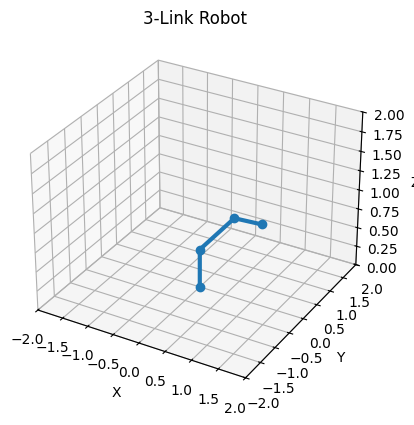

In [ ]:
l1, l2, l3 = 0.5, 0.7, 0.5
theta1, theta2, theta3 = np.pi/4, np.pi/6, -np.pi/4

p0, p1, p2, p3 = fk_3link(theta1, theta2, theta3, l1, l2, l3)
plot_robot(p0, p1, p2, p3)


In [ ]:
def ik_3link(x, y, z, l1, l2, l3, elbow='up'):
    theta1 = np.arctan2(y, x)

    r2 = x**2 + y**2 + (z - l1)**2
    cos_t3 = (r2 - (l2**2 + l3**2)) / (2 * l2 * l3)
    cos_t3 = np.clip(cos_t3, -1, 1)

    sin_t3 = np.sqrt(1 - cos_t3**2)
    if elbow == 'down':
        sin_t3 = -sin_t3

    theta3 = np.arctan2(sin_t3, cos_t3)

    rho = np.sqrt(x**2 + y**2)
    k1 = l2 + l3 * cos_t3
    k2 = l3 * sin_t3

    theta2 = np.arctan2(z - l1, rho) - np.arctan2(k2, k1)

    return theta1, theta2, theta3


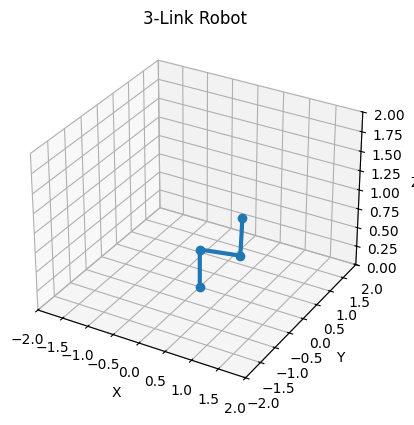

In [ ]:
# target
x, y, z = 0.6, 0.4, 0.9

theta1, theta2, theta3 = ik_3link(x, y, z, l1, l2, l3, elbow='up')
p0, p1, p2, p3 = fk_3link(theta1, theta2, theta3, l1, l2, l3)

plot_robot(p0, p1, p2, p3)


In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


In [ ]:
def plot_robot_from_angles(theta1, theta2, theta3, l1, l2, l3):
    p0 = np.array([0, 0, 0])
    p1 = np.array([0, 0, l1])

    x2 = np.cos(theta1) * l2 * np.cos(theta2)
    y2 = np.sin(theta1) * l2 * np.cos(theta2)
    z2 = l1 + l2 * np.sin(theta2)
    p2 = np.array([x2, y2, z2])

    x3 = np.cos(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2+theta3))
    y3 = np.sin(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2+theta3))
    z3 = l1 + l2*np.sin(theta2) + l3*np.sin(theta2+theta3)
    p3 = np.array([x3, y3, z3])

    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(projection='3d')

    ax.plot(
        [p0[0], p1[0], p2[0], p3[0]],
        [p0[1], p1[1], p2[1], p3[1]],
        [p0[2], p1[2], p2[2], p3[2]],
        '-o', linewidth=3
    )

    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_zlim(0,2)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()


In [ ]:
l1, l2, l3 = 0.5, 0.7, 0.5

widgets.interact(
    plot_robot_from_angles,
    theta1=widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.05, value=0),
    theta2=widgets.FloatSlider(min=-np.pi/2, max=np.pi/2, step=0.05, value=0),
    theta3=widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.05, value=0),
    l1=widgets.fixed(l1),
    l2=widgets.fixed(l2),
    l3=widgets.fixed(l3),
)


interactive(children=(FloatSlider(value=0.0, description='theta1', max=3.141592653589793, min=-3.1415926535897…

<function __main__.plot_robot_from_angles(theta1, theta2, theta3, l1, l2, l3)>

In [ ]:
def ik_3link(x, y, z, l1, l2, l3, elbow_up=True):
    theta1 = np.arctan2(y, x)

    r2 = x**2 + y**2 + (z-l1)**2
    cos_t3 = (r2 - (l2**2 + l3**2)) / (2*l2*l3)
    cos_t3 = np.clip(cos_t3, -1, 1)

    sin_t3 = np.sqrt(1 - cos_t3**2)
    if not elbow_up:
        sin_t3 = -sin_t3

    theta3 = np.arctan2(sin_t3, cos_t3)

    rho = np.sqrt(x**2 + y**2)
    k1 = l2 + l3*cos_t3
    k2 = l3*sin_t3

    theta2 = np.arctan2(z-l1, rho) - np.arctan2(k2, k1)

    return theta1, theta2, theta3


In [ ]:
def plot_robot_from_xyz(x, y, z, elbow_up):
    theta1, theta2, theta3 = ik_3link(x, y, z, l1, l2, l3, elbow_up)
    plot_robot_from_angles(theta1, theta2, theta3, l1, l2, l3)


In [ ]:
widgets.interact(
    plot_robot_from_xyz,
    x=widgets.FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.6),
    y=widgets.FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.2),
    z=widgets.FloatSlider(min=0.2, max=1.5, step=0.05, value=0.9),
    elbow_up=widgets.ToggleButtons(
        options=[('Solution A', True), ('Solution B', False)],
        value=True
    )
)


interactive(children=(FloatSlider(value=0.6, description='x', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_robot_from_xyz(x, y, z, elbow_up)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Video



In [ ]:
def fk_3link(theta1, theta2, theta3, l1, l2, l3):
    p0 = np.array([0, 0, 0])
    p1 = np.array([0, 0, l1])

    x2 = np.cos(theta1) * l2 * np.cos(theta2)
    y2 = np.sin(theta1) * l2 * np.cos(theta2)
    z2 = l1 + l2 * np.sin(theta2)
    p2 = np.array([x2, y2, z2])

    x3 = np.cos(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2+theta3))
    y3 = np.sin(theta1) * (l2*np.cos(theta2) + l3*np.cos(theta2+theta3))
    z3 = l1 + l2*np.sin(theta2) + l3*np.sin(theta2+theta3)
    p3 = np.array([x3, y3, z3])

    return p0, p1, p2, p3


In [ ]:
def ik_3link(x, y, z, l1, l2, l3, elbow_up=True):
    theta1 = np.arctan2(y, x)

    r2 = x**2 + y**2 + (z - l1)**2
    cos_t3 = (r2 - (l2**2 + l3**2)) / (2*l2*l3)
    cos_t3 = np.clip(cos_t3, -1, 1)

    sin_t3 = np.sqrt(1 - cos_t3**2)
    if not elbow_up:
        sin_t3 = -sin_t3

    theta3 = np.arctan2(sin_t3, cos_t3)

    rho = np.sqrt(x**2 + y**2)
    k1 = l2 + l3*cos_t3
    k2 = l3*sin_t3

    theta2 = np.arctan2(z - l1, rho) - np.arctan2(k2, k1)

    return np.array([theta1, theta2, theta3])


In [ ]:
def sample_random():
    return np.array([
        np.random.uniform(-np.pi, np.pi),
        np.random.uniform(-np.pi/2, np.pi/2),
        np.random.uniform(-np.pi, np.pi)
    ])


In [ ]:
def nearest(tree, q_rand):
    dists = [np.linalg.norm(q - q_rand) for q in tree]
    return tree[np.argmin(dists)]


In [ ]:
def steer(q_near, q_rand, step=0.15):
    direction = q_rand - q_near
    dist = np.linalg.norm(direction)
    if dist < step:
        return q_rand
    return q_near + direction / dist * step


In [ ]:
def is_goal_pos(q, p_goal, tol=0.05):
    _, _, _, p3 = fk_3link(*q, l1, l2, l3)
    return np.linalg.norm(p3 - p_goal) < tol


In [ ]:
# def rrt(q_start, p_goal, max_iter=8000):
#     tree = [q_start]
#     parent = {tuple(q_start): None}

#     for _ in range(max_iter):
#         q_rand = sample_random()
#         q_near = nearest(tree, q_rand)
#         q_new = steer(q_near, q_rand)

#         q_new[1] = np.clip(q_new[1], -np.pi/2, np.pi/2)

#         if tuple(q_new) in parent:
#             continue

#         tree.append(q_new)
#         parent[tuple(q_new)] = q_near

#         if is_goal_pos(q_new, p_goal):
#             print("Goal reached (position)")
#             return parent, q_new

#     print("Failed")
#     return None, None



In [ ]:
def rrt(q_start, p_goal, max_iter=8000):
    tree = [q_start]
    parent = {tuple(q_start): None}

    for _ in range(max_iter):

        # 🔥 10%の確率でゴール方向へ
        if np.random.rand() < 0.1:
            q_rand = ik_3link(*p_goal, l1, l2, l3)
        else:
            q_rand = sample_random()

        q_near = nearest(tree, q_rand)
        q_new = steer(q_near, q_rand)

        q_new[1] = np.clip(q_new[1], -np.pi/2, np.pi/2)

        if tuple(q_new) in parent:
            continue

        tree.append(q_new)
        parent[tuple(q_new)] = q_near

        if is_goal_pos(q_new, p_goal, tol=0.1):  # ← tol少し緩める
            print("Goal reached (position)")
            return parent, q_new

    print("Failed")
    return None, None


In [ ]:
def extract_path(parent, q_goal):
    path = [q_goal]
    q = q_goal
    while parent[tuple(q)] is not None:
        q = parent[tuple(q)]
        path.append(q)
    return path[::-1]


In [ ]:
def smooth_path(path, steps=10):
    smooth = []
    for i in range(len(path)-1):
        for a in np.linspace(0, 1, steps):
            smooth.append((1-a)*path[i] + a*path[i+1])
    smooth.append(path[-1])
    return np.array(smooth)


In [ ]:
def animate_path(path_q, l1, l2, l3):
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(projection='3d')

    line, = ax.plot([], [], [], '-o', linewidth=3)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_zlim(0, 2)

    def update(i):
        t1, t2, t3 = path_q[i]
        p0, p1, p2, p3 = fk_3link(t1, t2, t3, l1, l2, l3)

        xs = [p0[0], p1[0], p2[0], p3[0]]
        ys = [p0[1], p1[1], p2[1], p3[1]]
        zs = [p0[2], p1[2], p2[2], p3[2]]

        line.set_data(xs, ys)
        line.set_3d_properties(zs)
        return line,

    ani = animation.FuncAnimation(fig, update,
                                  frames=len(path_q),
                                  interval=100)
    return ani


Goal reached (position)


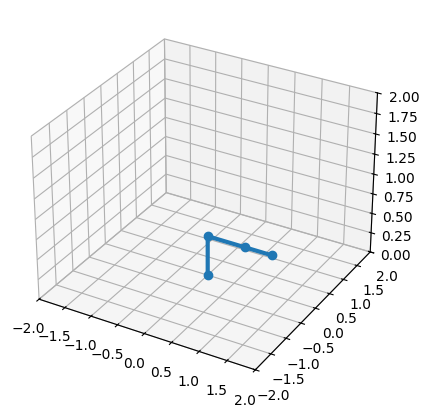

In [ ]:
# リンク長
l1, l2, l3 = 0.5, 0.7, 0.5

# start / goal
q_start = np.array([0.0, 0.0, 0.0])
p_goal = np.array([0.6, 0.4, 0.9])

# RRT
parent, q_goal_reached = rrt(q_start, p_goal)

if parent is None:
    raise RuntimeError("RRT failed to find a path")

path = extract_path(parent, q_goal_reached)

# smoothing
path_smooth = smooth_path(np.array(path), steps=10)

# animation
ani = animate_path(path_smooth, l1, l2, l3)
ani



In [ ]:
print(len(path_smooth))
print(path_smooth[0], path_smooth[-1])


131
[0. 0. 0.] [ 0.58760249 -0.11594398  1.54104454]


In [ ]:
from matplotlib.animation import FFMpegWriter

writer = FFMpegWriter(fps=10, bitrate=1800)
ani.save("rrt_3link.mp4", writer=writer)
plt.close()
Video("rrt_3link.mp4")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets

# パラメータ設定 (L1, L2, L3 は固定)
L1, L2, L3 = 0.5, 0.7, 0.5

def plot_combined_view(step):
    # RRT*で見つけたパス (path) から現在のステップの角度を取得
    # もしpathが計算されていない場合は初期値を表示
    try:
        theta1, theta2, theta3 = path[step]
    except:
        theta1, theta2, theta3 = 0, 0, 0

    # --- 左側：実際のロボットアーム (Workspace) ---
    p0 = np.array([0, 0, 0])
    p1 = np.array([0, 0, L1])

    x2 = np.cos(theta1) * L2 * np.cos(theta2)
    y2 = np.sin(theta1) * L2 * np.cos(theta2)
    z2 = L1 + L2 * np.sin(theta2)
    p2 = np.array([x2, y2, z2])

    x3 = np.cos(theta1) * (L2*np.cos(theta2) + L3*np.cos(theta2+theta3))
    y3 = np.sin(theta1) * (L2*np.cos(theta2) + L3*np.cos(theta2+theta3))
    z3 = L1 + L2*np.sin(theta2) + L3*np.sin(theta2+theta3)
    p3 = np.array([x3, y3, z3])

    fig = plt.figure(figsize=(12, 5))

    # ロボットアームの描画
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot([p0[0], p1[0], p2[0], p3[0]],
             [p0[1], p1[1], p2[1], p3[1]],
             [p0[2], p1[2], p2[2], p3[2]], '-o', linewidth=5, markersize=8)
    ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5); ax1.set_zlim(0, 2)
    ax1.set_title(f"Robot Pose at Step {step}")

    # --- 右側：探索空間での位置 (C-Space) ---
    ax2 = fig.add_subplot(122, projection='3d')
    path_np = np.array(path)
    # 全体のパスを薄く描画
    ax2.plot(path_np[:,0], path_np[:,1], path_np[:,2], color='red', alpha=0.3)
    # 現在の地点を強調
    ax2.scatter(theta1, theta2, theta3, color='blue', s=100)

    ax2.set_xlabel("Theta 1"); ax2.set_ylabel("Theta 2"); ax2.set_zlabel("Theta 3")
    ax2.set_title("Current Point in C-Space")

    plt.tight_layout()
    plt.show()

# パスが計算された後にこれを実行
widgets.interact(
    plot_combined_view,
    step=widgets.IntSlider(min=0, max=len(path)-1, step=1, value=0, description='Path Step')
)

interactive(children=(IntSlider(value=0, description='Path Step', max=25), Output()), _dom_classes=('widget-in…

<function __main__.plot_combined_view(step)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets

# パラメータ設定 (L1, L2, L3 は固定)
L1, L2, L3 = 0.5, 0.7, 0.5

def plot_combined_view(step):
    # RRT*で見つけたパス (path) と 全ノード (nodes) を使用
    try:
        theta1, theta2, theta3 = path[step]
    except:
        theta1, theta2, theta3 = start_angles[0], start_angles[1], start_angles[2]

    fig = plt.figure(figsize=(15, 7))

    # ==========================================
    # 1. 左側：実際のロボットアーム (Workspace)
    # ==========================================
    p0 = np.array([0, 0, 0])
    p1 = np.array([0, 0, L1])
    x2 = np.cos(theta1) * L2 * np.cos(theta2)
    y2 = np.sin(theta1) * L2 * np.cos(theta2)
    z2 = L1 + L2 * np.sin(theta2)
    p2 = np.array([x2, y2, z2])
    x3 = np.cos(theta1) * (L2*np.cos(theta2) + L3*np.cos(theta2+theta3))
    y3 = np.sin(theta1) * (L2*np.cos(theta2) + L3*np.cos(theta2+theta3))
    z3 = L1 + L2*np.sin(theta2) + L3*np.sin(theta2+theta3)
    p3 = np.array([x3, y3, z3])

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot([p0[0], p1[0], p2[0], p3[0]],
             [p0[1], p1[1], p2[1], p3[1]],
             [p0[2], p1[2], p2[2], p3[2]], '-o', linewidth=6, markersize=8, color='navy')
    ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5); ax1.set_zlim(0, 2)
    ax1.set_title(f"Robot Workspace Pose (Step {step})")
    ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

    # ==========================================
    # 2. 右側：構成空間 (C-Space) の詳細可視化
    # ==========================================
    ax2 = fig.add_subplot(122, projection='3d')

    # --- 探索木 (RRT* Tree) の描画 ---
    # すべてのノードとその親を結ぶ線を描画することで「木」を表現
    for n in nodes:
        if n.parent is not None:
            ax2.plot([n.point[0], n.parent.point[0]],
                     [n.point[1], n.parent.point[1]],
                     [n.point[2], n.parent.point[2]],
                     color='cyan', linewidth=0.5, alpha=0.3)

    # --- 障害物 (Obstacles) の描画 ---
    for obs in obstacles_cspace:
        # 3Dの立方体を描画するための簡易的な枠組み
        dx = [obs['min'][0], obs['max'][0]]
        dy = [obs['min'][1], obs['max'][1]]
        dz = [obs['min'][2], obs['max'][2]]
        for x in dx:
            for y in dy:
                ax2.plot([x, x], [y, y], [dz[0], dz[1]], color='red', alpha=0.5)
            for z in dz:
                ax2.plot([x, x], [dy[0], dy[1]], [z, z], color='red', alpha=0.5)
        for y in dy:
            for z in dz:
                ax2.plot([dx[0], dx[1]], [y, y], [z, z], color='red', alpha=0.5)

    # --- パスと現在地点 ---
    path_np = np.array(path)
    ax2.plot(path_np[:,0], path_np[:,1], path_np[:,2], color='yellow', linewidth=3, label='Optimized Path')
    ax2.scatter(theta1, theta2, theta3, color='blue', s=150, edgecolors='white', label='Current State')

    # スタートとゴール
    ax2.scatter(start_angles[0], start_angles[1], start_angles[2], color='blue', s=100, marker='o')
    ax2.scatter(goal_angles[0], goal_angles[1], goal_angles[2], color='green', s=150, marker='*')

    ax2.set_xlim(-180, 180); ax2.set_ylim(-90, 90); ax2.set_zlim(-180, 180)
    ax2.set_xlabel("Theta 1"); ax2.set_ylabel("Theta 2"); ax2.set_zlabel("Theta 3")
    ax2.set_title("C-Space: RRT* Tree & Obstacles")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# インタラクティブ表示
widgets.interact(
    plot_combined_view,
    step=widgets.IntSlider(min=0, max=len(path)-1, step=1, value=0, description='Path Step')
)

interactive(children=(IntSlider(value=0, description='Path Step', max=25), Output()), _dom_classes=('widget-in…

<function __main__.plot_combined_view(step)>